In [1]:
# testing the feature generation from communities
from lfr_generator import generate_features_from_communities
generate_features_from_communities(true_labels=[0, 1, 2, 3, 0, 2, 1, 1, 2, 3], 
                                   mode = 'gaussian', num_features=5, n_clusters_f=5)

array([[ 0.97125674, -0.76460365,  3.03460073,  0.61124548,  0.71385807],
       [-0.02347035, -1.90776535,  1.54931914, -2.94077968, -3.37411828],
       [-2.13268081, -1.18816213, -0.1601611 , -2.95068314, -2.79929842],
       [ 2.07711242, -0.32439875, -0.05932338, -1.26684347, -0.2444996 ],
       [ 0.68870531, -1.24856614, -0.46146476,  3.41166551, -0.9437072 ],
       [-2.32058867, -2.63486623, -0.58625996, -1.43831495, -1.86405897],
       [ 0.08508547,  0.08766473,  1.17408875, -3.52106448, -3.61112272],
       [-2.31081628,  0.29297938,  0.24135883, -3.7242819 , -1.80792898],
       [-1.87211851, -0.91947954,  0.84085373, -2.61057371, -2.52198551],
       [ 3.51154167,  0.40453944,  1.61239653, -2.12955499,  2.42939772]])

In [2]:
import attacks
true_labels = [0, 1, 2, 3, 0, 2, 1, 1, 2, 3]
target_list = [0, 1, 2, 4]
M1 = attacks.compute_M1(target_list=target_list, labels=true_labels)
print("M1 matrix:")
print(M1)

M1 matrix:
0.3333333333333333


In [3]:
import attacks
true_labels = [0, 1, 2, 3, 0, 2, 1, 1, 2, 3]
target_list = [0, 1, 2, 4]
M2 = attacks.compute_M2(target_list=target_list, labels=true_labels)
print("M2 matrix:")
print(M2)

M2 matrix:
0.6666666666666666


## LFR graph generation

In [1]:
from lfr_generator import generate_featurized_lfr_graph
import random
from tqdm import tqdm
import numpy as np

sigma_c_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]
mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
realizations = 1
n = 1000  # Number of nodes in the graph
b_percentage = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] # % Budget for the DICE attack
# random.seed(42)  # For reproducibility
realizations = 10  # Number of realizations for each parameter combination
nodes_per_community = {}
min_community = 10  # Minimum community size

for mu in mu_values:
    for sigma_c in sigma_c_values:
        print(f"Generating graphs with mu={mu}, sigma_c={sigma_c}")
        G, data, true_labels = generate_featurized_lfr_graph(
            mu=mu, n=n,
            min_community=min_community,  # Minimum community size
            feature_mode='gaussian', sigma_c=sigma_c, 
            seed=42
        )
        print(f"Generated graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
        number_of_communities = len(set(true_labels))
        print(f"Number of communities: {number_of_communities}")
        for community in set(true_labels):
            # print(f"Community {community} has {list(true_labels).count(community)} nodes")
            if community not in nodes_per_community:
                nodes_per_community[community] = [list(true_labels).count(community)]
            else:
                nodes_per_community[community] += [list(true_labels).count(community)]
            # for b in b_percentage:
            #     print(f"{b*100} % budget of community {community} nodes = {int(b * list(true_labels).count(community))}")
for community, counts in nodes_per_community.items():
    print(f"Community {community} has {np.mean(counts)} realizations with node counts: {counts}")


Generating graphs with mu=0.01, sigma_c=0.01
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=0.1
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=0.5
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=1
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=2
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=5
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=10
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.1, sigma_c=0.01
Generated graph with 1000 nodes and 17448 edges
Number of communities: 25
Generating graphs with mu=0.1, sigma_c=0.1
Generated graph wit

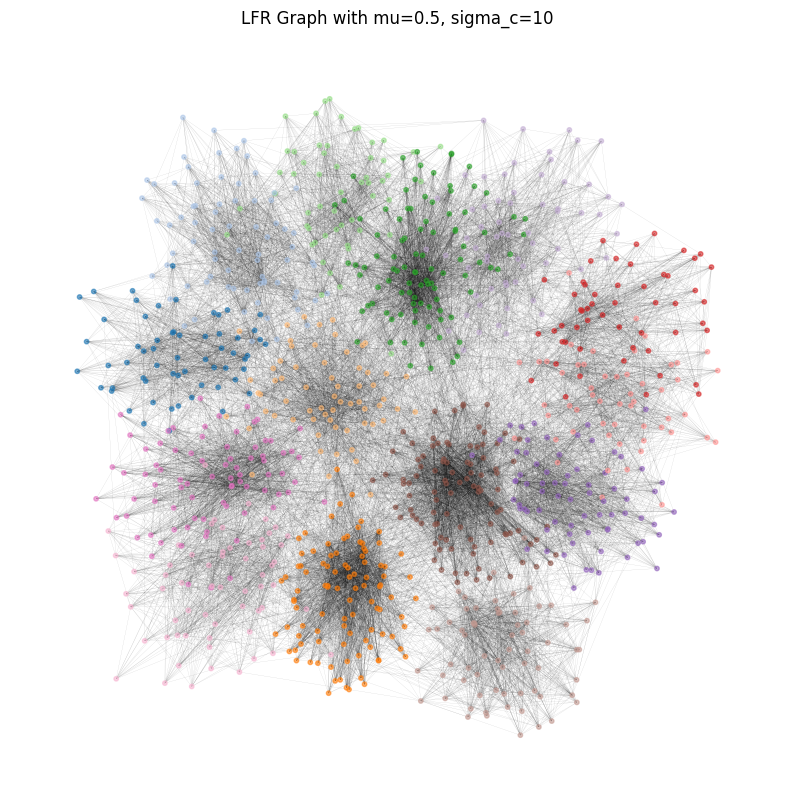

In [37]:
from lfr_generator import visualize_lfr_graph
from lfr_generator import generate_featurized_lfr_graph
G, data, true_labels = generate_featurized_lfr_graph(
            mu=0.1, n=1000,
            min_community = 50,  # Minimum community size
            feature_mode='gaussian', sigma_c=1, 
            seed=41
        )
labels_dict = {}
for i, label in enumerate(true_labels):
        labels_dict[i] = label
visualize_lfr_graph(G, labels_dict, title=f"LFR Graph with mu={mu}, sigma_c={sigma_c}")


In [ ]:
G, data, true_labels = generate_featurized_lfr_graph(
            mu=0.01, n=1000,
            min_community = 10,  # Minimum community size
            feature_mode='gaussian', sigma_c=1, 
            seed=42
        )
target_label = 0
target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
pred_labels = train_model(data, true_labels)
ecs_initial = attacks.compute_ECS(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)
target_size = len(target_community)
M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
print(f"Initial ECS: {ecs_initial}, NMI: {nmi}")
print(f"Initial M1: {M1}, M2: {M2}")
G_attacked = attacks.dice_community_attack(G.copy(), 0, bb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random
import torch
import networkx as nx
from lfr_generator import generate_featurized_lfr_graph
import attacks
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score
import time

def train_model(data, true_labels, num_features=32):
    import dmon
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_clusters = len(set(true_labels))
    model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True).to(device)
    # model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    data = data.to(device)  # send features and edges to GPU
    for epoch in range(201):
        model.train()
        optimizer.zero_grad()
        ca, loss = model(data.x, data.edge_index)
        loss.backward()
        optimizer.step()
        # if epoch % 20 == 0:
        #     print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    model.eval()
    data = data.to(device)  # ensure data is on same device for eval
    ca, _ = model(data.x, data.edge_index)
    pred_labels = ca.argmax(dim=1).cpu().numpy()  # bring prediction back to CPU
    return pred_labels

num_features =  32
sigma_c_values = [1]
# mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.2]
realizations = 1
n = 1000  # Number of nodes in the graph
b_percentages = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] # % Budget for the DICE attack
seed = 42  # For reproducibility
min_community = 10  # Minimum community size

results = {}  # {mu: {sigma_c: {b: {DICE: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results[mu][sigma_c] = {p: {"DICE": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                    "DICEHDG": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                    "DICEHDGCD": {"nmi": [], "ecs": [], "M1": [], "M2": []},
                                    "DICECDHD": {"nmi": [], "ecs": [], "M1": [], "M2": []}} for p in b_percentages}
        results[mu][sigma_c][0] = {"DICE": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                   "DICEHDG": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                   "DICEHDGCD": {"nmi": [], "ecs": [], "M1": [], "M2": []},
                                   "DICECDHD": {"nmi": [], "ecs": [], "M1": [], "M2": []}}
        G, data, true_labels = generate_featurized_lfr_graph(
                mu=mu, n=n, min_community=min_community,
                feature_mode='gaussian', sigma_c=sigma_c, seed=seed)
        number_of_communities = len(set(true_labels))
        print(f"Number of communities: {number_of_communities}")
        pred_labels = train_model(data, true_labels)
        ecs_initial = attacks.compute_ECS(true_labels, pred_labels)
        nmi = normalized_mutual_info_score(true_labels, pred_labels)
        for target_label in set(true_labels):
            if target_label == 0:
                target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
                target_size = len(target_community)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
                # Store results for the original graph
                results[mu][sigma_c][0]['DICE']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICE']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICE']["M1"].append(M1)
                results[mu][sigma_c][0]['DICE']["M2"].append(M2)

                results[mu][sigma_c][0]['DICEHDG']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICEHDG']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICEHDG']["M1"].append(M1)
                results[mu][sigma_c][0]['DICEHDG']["M2"].append(M2)

                results[mu][sigma_c][0]['DICEHDGCD']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICEHDGCD']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICEHDGCD']["M1"].append(M1)
                results[mu][sigma_c][0]['DICEHDGCD']["M2"].append(M2)

                results[mu][sigma_c][0]['DICECDHD']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICECDHD']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICECDHD']["M1"].append(M1)
                results[mu][sigma_c][0]['DICECDHD']["M2"].append(M2)

                # Budget as % of intra-community edges
                G_target = G.subgraph(target_community)
                intra_edges = G_target.number_of_edges()
                for p in b_percentages:
                    bb = int(np.round(p * intra_edges))
                    for realization in range(realizations):
                        print(f"Applying DICE attack with budget {bb} on target community {target_label}")
                        # print(f"Realization {realization+1}/{realizations} | mu={mu} sigma_c={sigma_c} label={target_label} b={bb}")
                        start = time.time()
                        # Normal DICE
                        G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                        data_attacked = from_networkx(G_attacked)
                        data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                        pred_labels_attacked = train_model(data_attacked, true_labels)

                        nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                        ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                        M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                        M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)
                        elapsed_time = time.time() - start
                        results[mu][sigma_c][p]['DICE']["nmi"].append(nmi)
                        results[mu][sigma_c][p]['DICE']["ecs"].append(ecs)
                        results[mu][sigma_c][p]['DICE']["M1"].append(M1)
                        results[mu][sigma_c][p]['DICE']["M2"].append(M2)

                        # DICE with attachment to high degree global
                        G_attacked_hd_global = attacks.dicehd_community_attack(G.copy(), target_community, bb)
                        data_attacked_hd_global = from_networkx(G_attacked_hd_global)
                        data_attacked_hd_global.x = torch.stack([G_attacked_hd_global.nodes[i]['x'] for i in range(len(G_attacked_hd_global))])
                        pred_labels_attacked_hd_global = train_model(data_attacked_hd_global, true_labels)

                        nmi_hd_global = normalized_mutual_info_score(true_labels, pred_labels_attacked_hd_global)
                        ecs_hd_global = attacks.compute_ECS(true_labels, pred_labels_attacked_hd_global)
                        M1_hd_global = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked_hd_global)
                        M2_hd_global = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked_hd_global)

                        results[mu][sigma_c][p]['DICEHDG']["nmi"].append(nmi_hd_global)
                        results[mu][sigma_c][p]['DICEHDG']["ecs"].append(ecs_hd_global)
                        results[mu][sigma_c][p]['DICEHDG']["M1"].append(M1_hd_global)
                        results[mu][sigma_c][p]['DICEHDG']["M2"].append(M2_hd_global)

                        # DICE with attachment to high degree global from other communities
                        G_attacked_hdcd = attacks.dicehdcd_community_attack(G.copy(), target_community, true_labels, bb)
                        data_attacked_hdcd = from_networkx(G_attacked_hdcd)
                        data_attacked_hdcd.x = torch.stack([G_attacked_hdcd.nodes[i]['x'] for i in range(len(G_attacked_hdcd))])
                        pred_labels_attacked_hdcd = train_model(data_attacked_hdcd, true_labels)

                        nmi_hdcd = normalized_mutual_info_score(true_labels, pred_labels_attacked_hdcd)
                        ecs_hdcd = attacks.compute_ECS(true_labels, pred_labels_attacked_hdcd)
                        M1_hdcd = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked_hdcd)
                        M2_hdcd = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked_hdcd)

                        results[mu][sigma_c][p]['DICEHDGCD']["nmi"].append(nmi_hdcd)
                        results[mu][sigma_c][p]['DICEHDGCD']["ecs"].append(ecs_hdcd)
                        results[mu][sigma_c][p]['DICEHDGCD']["M1"].append(M1_hdcd)
                        results[mu][sigma_c][p]['DICEHDGCD']["M2"].append(M2_hdcd)

                        # DICE with attachment to high degree local from other communities
                        G_attacked_cdhd = attacks.dicecdhd_community_attack(G.copy(), target_community, true_labels, bb)
                        data_attacked_cdhd = from_networkx(G_attacked_cdhd)
                        data_attacked_cdhd.x = torch.stack([G_attacked_cdhd.nodes[i]['x'] for i in range(len(G_attacked_cdhd))])
                        pred_labels_attacked_cdhd = train_model(data_attacked_cdhd, true_labels)

                        nmi_cdhd = normalized_mutual_info_score(true_labels, pred_labels_attacked_cdhd)
                        ecs_cdhd = attacks.compute_ECS(true_labels, pred_labels_attacked_cdhd)
                        M1_cdhd = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked_cdhd)
                        M2_cdhd = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked_cdhd)

                        results[mu][sigma_c][p]['DICECDHD']["nmi"].append(nmi_cdhd)
                        results[mu][sigma_c][p]['DICECDHD']["ecs"].append(ecs_cdhd)
                        results[mu][sigma_c][p]['DICECDHD']["M1"].append(M1_cdhd)
                        results[mu][sigma_c][p]['DICECDHD']["M2"].append(M2_cdhd)
                        elapsed_time = time.time() - start

                    print(f"Completed budget {p} for target label {target_label} with elapsed time {elapsed_time:.2f} seconds")


KeyboardInterrupt: 

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

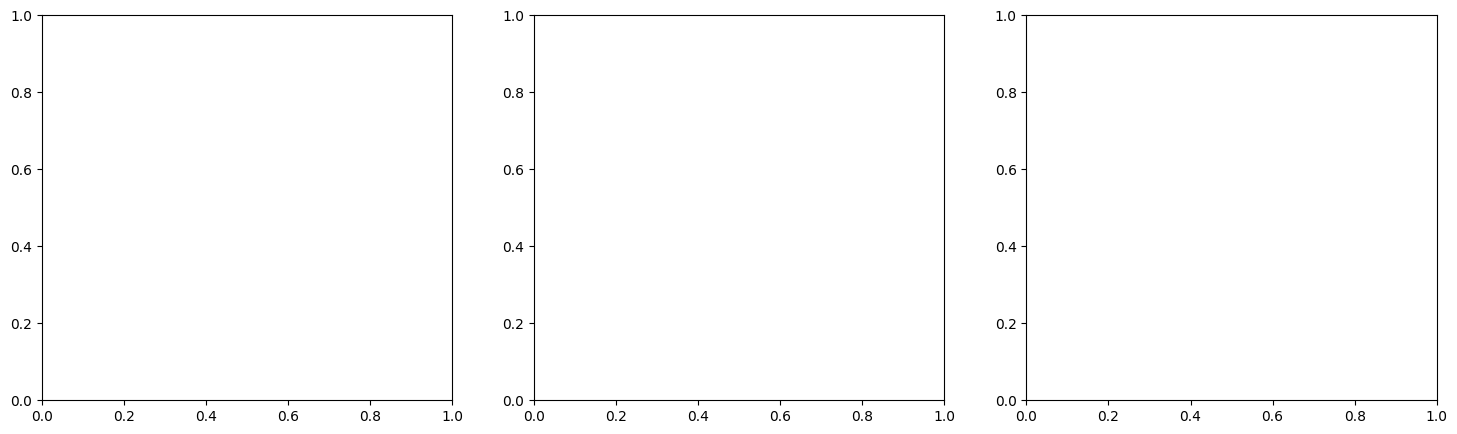

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Use actual values from your experiment:
sigma_c_values = [1]  
mu_values = [0.01]
b_percentages = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
attacks = ['DICE', 'DICEHDGCD']
metrics = ['ecs', 'nmi', 'M1', 'M2']

metric_styles = {
    'DICE': '-',
    'DICEHDGCD': '--'
}
metric_markers = {
    'DICE': 'o',
    'DICEHDGCD': 'x'
}
attack_labels = {'DICE': 'DICE', 'DICEHDGCD': 'DICE-HDCD'}
color_map = {s: c for s, c in zip(sigma_c_values, plt.cm.viridis(np.linspace(0, 1, len(sigma_c_values))))}

fig, axes = plt.subplots(len(mu_values), 3, figsize=(18, 5 * len(mu_values)), sharex=True)

for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        color = color_map[sigma_c]
        for attack in attacks:
            all_p = [0] + b_percentages

            # --- Column 0: ECS and NMI (solid for ECS, dotted for NMI) ---
            ecs_means = [np.mean(results[mu][sigma_c][p][attack]["ecs"]) for p in all_p]
            nmi_means = [np.mean(results[mu][sigma_c][p][attack]["nmi"]) for p in all_p]
            axes[idx, 0].plot(
                all_p, ecs_means, marker=metric_markers[attack], linestyle=metric_styles[attack],
                color=color, label=f"ECS {attack_labels[attack]} σ_c={sigma_c}"
            )
            axes[idx, 0].plot(
                all_p, nmi_means, marker=metric_markers[attack], linestyle=':', linewidth=2,
                color=color, label=f"NMI {attack_labels[attack]} σ_c={sigma_c}"
            )

            # --- Column 1: M1 ---
            M1_means = [np.mean(results[mu][sigma_c][p][attack]["M1"]) for p in all_p]
            axes[idx, 1].plot(
                all_p, M1_means, marker=metric_markers[attack], linestyle=metric_styles[attack],
                color=color, label=f"M1 {attack_labels[attack]} σ_c={sigma_c}"
            )

            # --- Column 2: M2 ---
            M2_means = [np.mean(results[mu][sigma_c][p][attack]["M2"]) for p in all_p]
            axes[idx, 2].plot(
                all_p, M2_means, marker=metric_markers[attack], linestyle=metric_styles[attack],
                color=color, label=f"M2 {attack_labels[attack]} σ_c={sigma_c}"
            )

    for col, metric in enumerate(["ECS/NMI", "M1", "M2"]):
        axes[idx, col].set_xlabel("DICE Budget b (fraction of intra-community edges)")
        axes[idx, col].set_xticks([0] + b_percentages)
        axes[idx, col].set_xticklabels([f"{int(p*100)}%" if p != 0 else "0" for p in [0] + b_percentages])
        axes[idx, col].set_ylabel(metric)
        axes[idx, col].set_title(f"{metric} (mu={mu})")
        axes[idx, col].grid(True)
        axes[idx, col].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()


In [18]:
import pickle

with open('dmon_attack_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Results saved to dmon_attack_results.pkl")


Results saved to dmon_attack_results.pkl


In [38]:
import pickle
with open('dmon_attack_results.pkl', 'rb') as f:
    results = pickle.load(f)


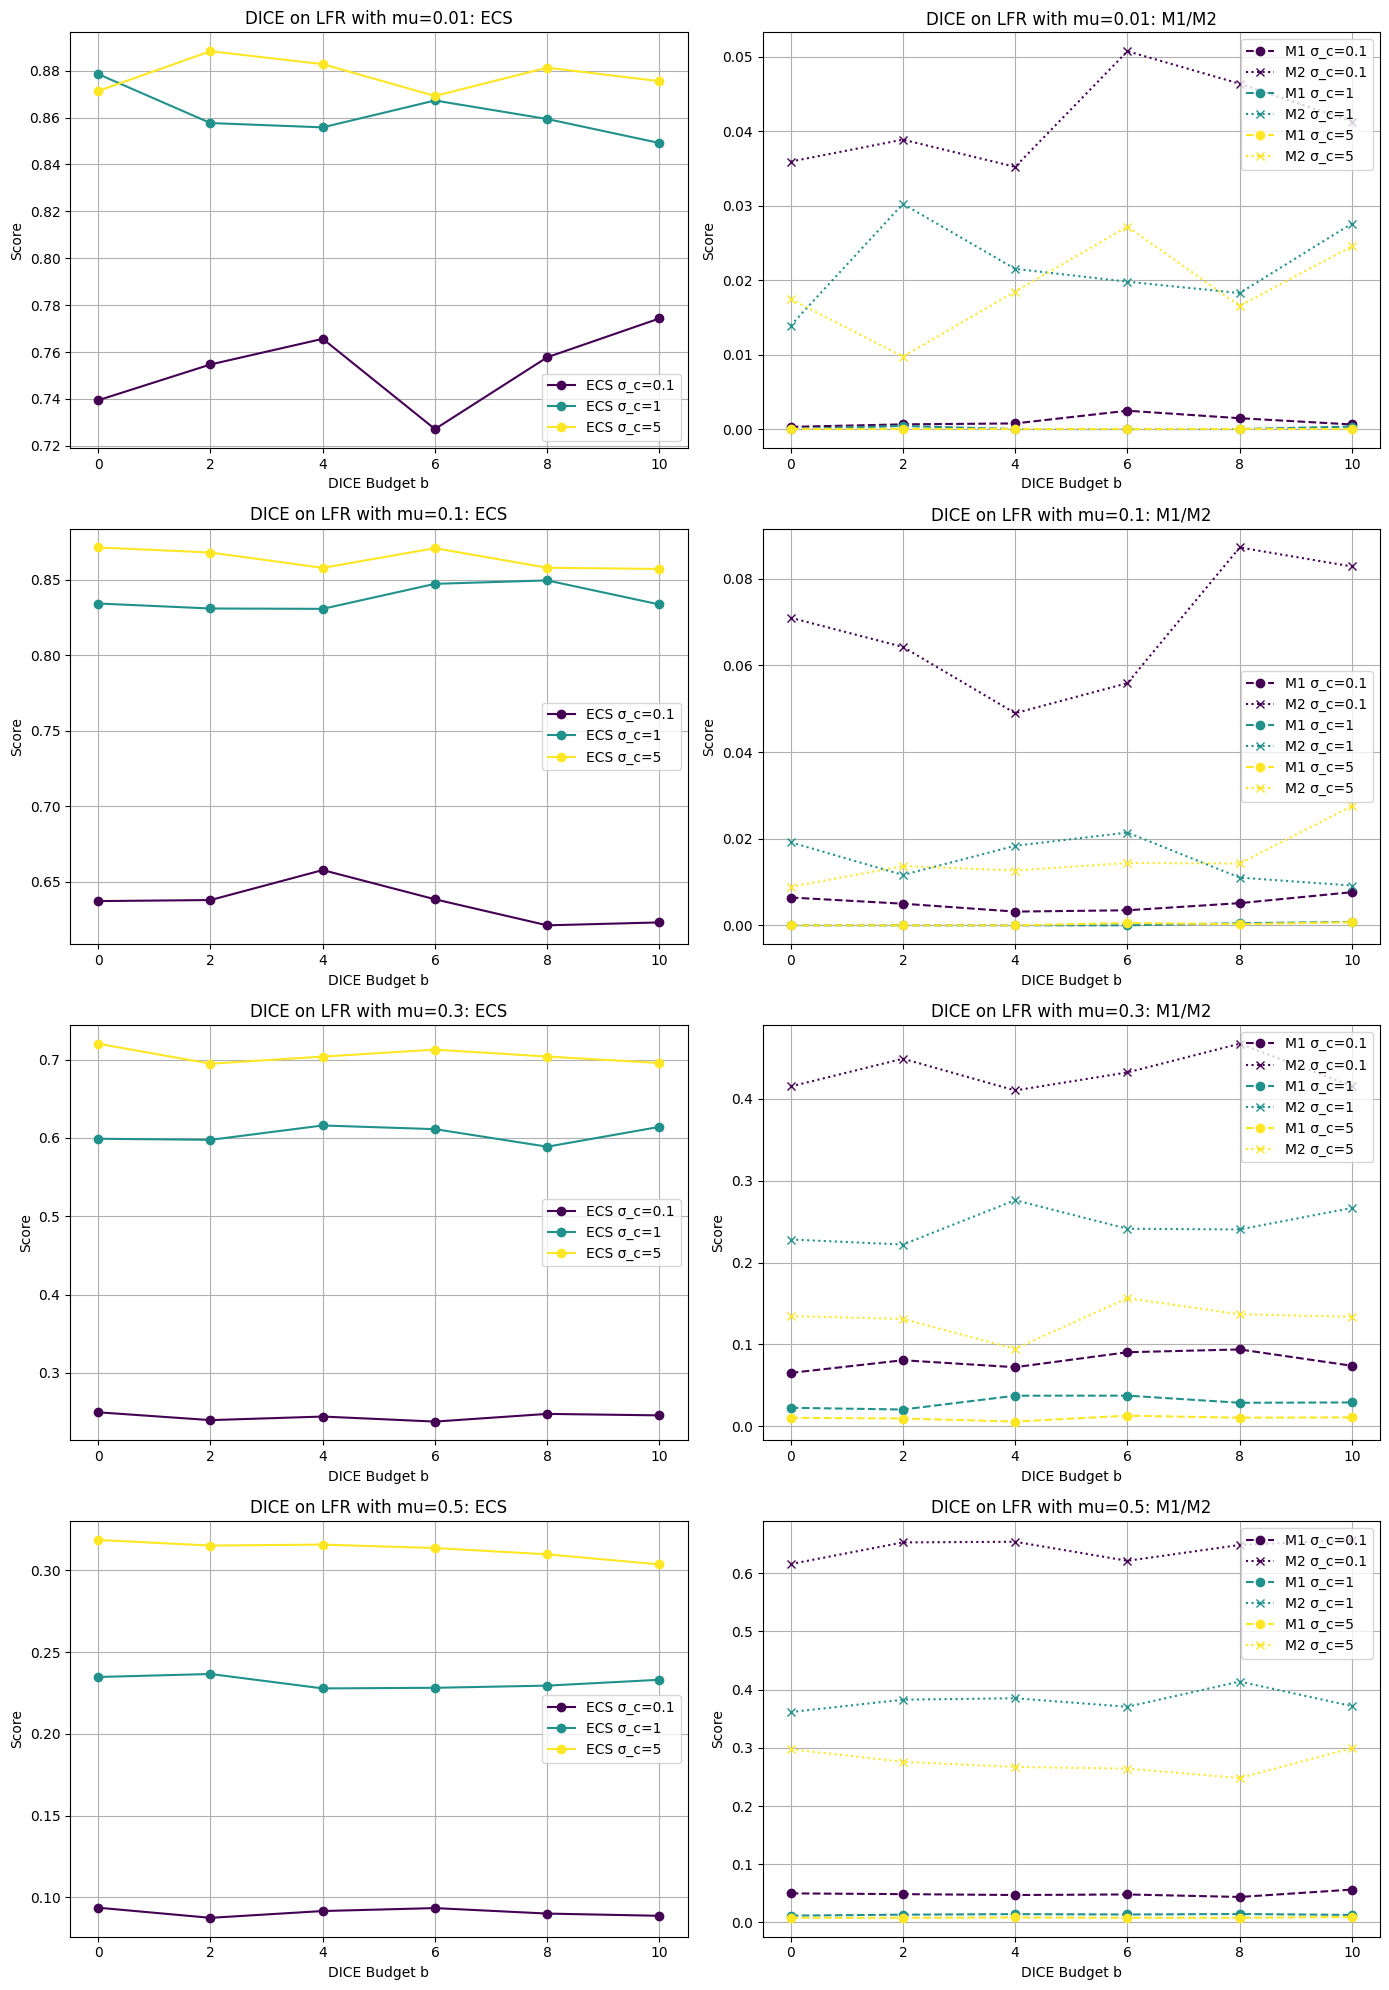

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

num_features = 16
sigma_c_values = [0.1, 1, 5]
# mu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.3,  0.5]
realizations = 10
n = 1000
b_values = [2, 4, 6, 8, 10]
target_label = 0
random.seed(42)  # For reproducibility
# Define colors for each sigma_c value, so colors are consistent across subplots
color_map = {s: c for s, c in zip(sigma_c_values, plt.cm.viridis(np.linspace(0, 1, len(sigma_c_values))))}

metric_styles = {
    'nmi': 'dotted',
    'ecs': 'solid',
    'M1': 'dashed',
    'M2': 'dotted'
}
metric_markers = {
    'nmi': 'x',
    'ecs': 'o',
    'M1': 'o',
    'M2': 'x'
}

fig, axes = plt.subplots(len(mu_values), 2, figsize=(14, 5 * len(mu_values)))

for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        color = color_map[sigma_c]
        # Column 1: NMI/ECS
        # nmi_means = [np.mean(results[mu][sigma_c][bb]["nmi"]) for bb in [0] + b_values]
        ecs_means = [np.mean(results[mu][sigma_c][bb]["ecs"]) for bb in [0] + b_values]
        # axes[idx, 0].plot([0] + b_values, nmi_means, marker=metric_markers['nmi'], linestyle=metric_styles['nmi'],
        #                   color=color, label=f'NMI σ_c={sigma_c}')
        axes[idx, 0].plot([0] + b_values, ecs_means, marker=metric_markers['ecs'], linestyle=metric_styles['ecs'],
                          color=color, label=f'ECS σ_c={sigma_c}')

        # Column 2: M1/M2
        M1_means = [np.mean(results[mu][sigma_c][bb]["M1"]) for bb in [0] + b_values]
        M2_means = [np.mean(results[mu][sigma_c][bb]["M2"]) for bb in [0] + b_values]

        axes[idx, 1].plot([0] + b_values, M1_means, marker=metric_markers['M1'], linestyle=metric_styles['M1'],
                          color=color, label=f'M1 σ_c={sigma_c}')
        axes[idx, 1].plot([0] + b_values, M2_means, marker=metric_markers['M2'], linestyle=metric_styles['M2'],
                          color=color, label=f'M2 σ_c={sigma_c}')


    axes[idx, 0].set_title(f"DICE on LFR with mu={mu}: ECS")
    axes[idx, 1].set_title(f"DICE on LFR with mu={mu}: M1/M2")
    for ax in axes[idx]:
        ax.set_xlabel("DICE Budget b")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()



b_valuw with % based on number of edges of targeted community 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from lfr_generator import generate_lfr_graph
import attacks
import random
import torch
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score

num_features = 32
sigma_c_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]
mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
realizations = 20
n = 1000
random.seed(42)  # For reproducibility

results1 = {}  # {mu: {sigma_c: {b: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results1[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results1[mu][sigma_c] = {}  # initialize 
        results1[mu][sigma_c][n] = {}
        G, data, true_labels = generate_lfr_graph(
            mu=mu, n=n, num_features=num_features, 
            feature_mode='gaussian', sigma_c=sigma_c)
        pred_labels = train_model(data, true_labels, num_features)
        ecs = attacks.compute_ECS(true_labels, pred_labels)
        # 
        for target_label in set(true_labels):
            target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
        
        M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
        M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)

        # Intra-community edge count for DICE budget
        G_target = G.subgraph(target_community)
        num_edges_target = G_target.number_of_edges()
        print(f"Target community {target_label} has {len(target_community)} nodes and {num_edges_target} edges.")
        # b_values = [max(1, int(p * num_edges_target / 100)) for p in range(1, 11)]  # 1% to 10%
        b_values = [int(np.round(p * num_edges_target / 100)) for p in range(1, 11)]

        # Store results for original (unattacked)
        if 0 not in results1[mu][sigma_c]:
            results1[mu][sigma_c][0] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
        results1[mu][sigma_c][0]["nmi"].append(nmi)
        results1[mu][sigma_c][0]["ecs"].append(ecs)
        results1[mu][sigma_c][0]["M1"].append(M1)
        results1[mu][sigma_c][0]["M2"].append(M2)

        for realization in tqdm(range(realizations), desc=f"sigma_c={sigma_c}"):
            print(f"Realization {realization + 1}/{realizations}")
            # Now run for each value of b
            for bb in b_values:
                if bb not in results1[mu][sigma_c]:
                    results1[mu][sigma_c][bb] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
                print(f"Applying DICE attack with budget {bb} on target community {target_label} (mu={mu}, sigma_c={sigma_c})")
                G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                data_attacked = from_networkx(G_attacked)
                data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                pred_labels_attacked = train_model(data_attacked, true_labels, num_features)
                nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)
                results1[mu][sigma_c][bb]["nmi"].append(nmi)
                results1[mu][sigma_c][bb]["ecs"].append(ecs)
                results1[mu][sigma_c][bb]["M1"].append(M1)
                results1[mu][sigma_c][bb]["M2"].append(M2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from lfr_generator import generate_lfr_graph
import attacks
import random
import torch
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score

num_features = 32
sigma_c_values = [0.1, 1, 2]
# mu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.3, 0.5]
realizations = 20
n = 1000
target_label = 0
num_features = 32
sigma_c_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]
mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
realizations = 20
n = 1000
random.seed(42)  # For reproducibility

results1 = {}  # {mu: {sigma_c: {b: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results1[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results1[mu][sigma_c] = {}  # initialize b-values as we go
        G, data, true_labels = generate_lfr_graph(
                mu=mu, n=n, num_features=num_features, 
                feature_mode='gaussian', sigma_c=sigma_c)
        pred_labels = train_model(data, true_labels, num_features)
        target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
        # nmi = normalized_mutual_info_score(true_labels, pred_labels)
        ecs = attacks.compute_ECS(true_labels, pred_labels)
        M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
        M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
        for realization in tqdm(range(realizations), desc=f"sigma_c={sigma_c}"):
            print(f"Realization {realization + 1}/{realizations}")
            # Intra-community edge count for DICE budget
            G_target = G.subgraph(target_community)
            num_edges_target = G_target.number_of_edges()
            print(f"Target community {target_label} has {len(target_community)} nodes and {num_edges_target} edges.")
            # b_values = [max(1, int(p * num_edges_target / 100)) for p in range(1, 11)]  # 1% to 10%
            b_values = [int(np.round(p * num_edges_target / 100)) for p in range(1, 11)]

            # Store results for original (unattacked)
            if 0 not in results1[mu][sigma_c]:
                results1[mu][sigma_c][0] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
            # results1[mu][sigma_c][0]["nmi"].append(nmi)
            results1[mu][sigma_c][0]["ecs"].append(ecs)
            results1[mu][sigma_c][0]["M1"].append(M1)
            results1[mu][sigma_c][0]["M2"].append(M2)

            # Now run for each value of b
            for bb in b_values:
                if bb not in results1[mu][sigma_c]:
                    results1[mu][sigma_c][bb] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
                print(f"Applying DICE attack with budget {bb} on target community {target_label} (mu={mu}, sigma_c={sigma_c})")
                G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                data_attacked = from_networkx(G_attacked)
                data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                pred_labels_attacked = train_model(data_attacked, true_labels, num_features)
                nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)
                results1[mu][sigma_c][bb]["nmi"].append(nmi)
                results1[mu][sigma_c][bb]["ecs"].append(ecs)
                results1[mu][sigma_c][bb]["M1"].append(M1)
                results1[mu][sigma_c][bb]["M2"].append(M2)


mu values:   0%|          | 0/4 [00:00<?, ?it/s]

Generating graphs for mu=0.01, sigma_c=0.1


Realization 1/20
Target community 0 has 15 nodes and 97 edges.
Applying DICE attack with budget 1 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 2 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 3 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 4 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 5 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 6 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 7 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 8 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 9 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 10 on target community 0 (mu=0.01, sigma_c=0.1)


Realization 2/20
Target community 0 has 15 nodes and 97 edges.
Applying DICE attack with budget 1 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 2 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 3 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 4 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 5 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 6 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 7 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 8 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 9 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 10 on target community 0 (mu=0.01, sigma_c=0.1)


Realization 3/20
Target community 0 has 15 nodes and 97 edges.
Applying DICE attack with budget 1 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 2 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 3 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 4 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 5 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 6 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 7 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 8 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 9 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 10 on target community 0 (mu=0.01, sigma_c=0.1)


...

Realization 17/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


Realization 18/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


Realization 19/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


Realization 20/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


mu values: 100%|██████████| 4/4 [8:59:07<00:00, 8086.78s/it]  


In [45]:
import pickle

with open('dmon_attack_results1_r20.pkl', 'wb') as f:
    pickle.dump(results1, f)
print("Results saved to dmon_attack_results1_r20.pkl")


Results saved to dmon_attack_results1_r20.pkl


In [5]:
for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        print(list(results1[mu][sigma_c].keys()))

KeyError: 0.01

KeyError: 0.01

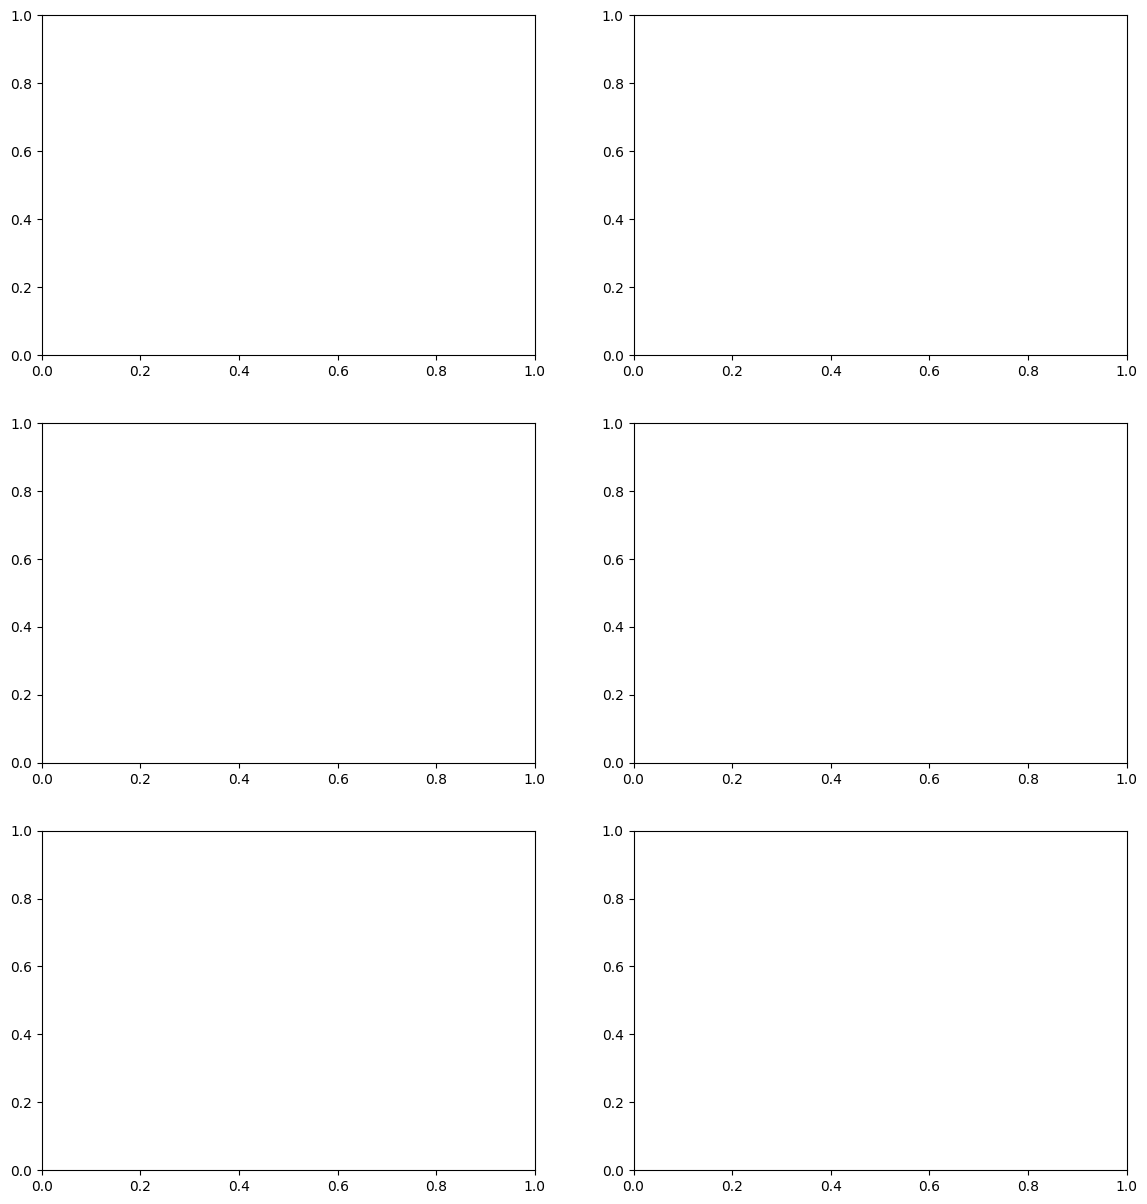

In [4]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pickle

with open('dmon_attack_results1_r20.pkl', 'rb') as f:
    results1 = pickle.load(f)

# Define colors for each sigma_c value, so colors are consistent across subplots
color_map = {s: c for s, c in zip(sigma_c_values, plt.cm.viridis(np.linspace(0, 1, len(sigma_c_values))))}

metric_styles = {
    'nmi': 'dotted',
    'ecs': 'solid',
    'M1': 'dashed',
    'M2': 'dotted'
}
metric_markers = {
    'nmi': 'x',
    'ecs': 'o',
    'M1': 'o',
    'M2': 'x'
}

fig, axes = plt.subplots(len(mu_values), 2, figsize=(14, 5 * len(mu_values)))

for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        color = color_map[sigma_c]
        
        # nmi_means = [np.mean(results1[mu][sigma_c][bb]["nmi"]) for bb in results1[mu][sigma_c].keys()]
        ecs_means = [np.mean(results1[mu][sigma_c][bb]["ecs"]) for bb in results1[mu][sigma_c].keys()]
        M1_means = [np.mean(results1[mu][sigma_c][bb]["M1"]) for bb in results1[mu][sigma_c].keys()]
        M2_means = [np.mean(results1[mu][sigma_c][bb]["M2"]) for bb in results1[mu][sigma_c].keys()]

        # ECS/NMI plot
        axes[idx, 0].plot(list(results1[mu][sigma_c].keys()), ecs_means, marker=metric_markers['ecs'], linestyle=metric_styles['ecs'],
                          color=color, label=f'ECS σ_c={sigma_c}')
        axes[idx, 0].plot(list(results1[mu][sigma_c].keys()), nmi_means, marker=metric_markers['nmi'], linestyle=metric_styles['nmi'],
                          color=color, label=f'NMI σ_c={sigma_c}')

        # M1/M2 plot
        axes[idx, 1].plot(list(results1[mu][sigma_c].keys()), M1_means, marker=metric_markers['M1'], linestyle=metric_styles['M1'],
                          color=color, label=f'M1 σ_c={sigma_c}')
        axes[idx, 1].plot(list(results1[mu][sigma_c].keys()), M2_means, marker=metric_markers['M2'], linestyle=metric_styles['M2'],
                          color=color, label=f'M2 σ_c={sigma_c}')

    axes[idx, 0].set_title(f"DICE on LFR with mu={mu}: ECS/NMI")
    axes[idx, 1].set_title(f"DICE on LFR with mu={mu}: M1/M2")
    for ax in axes[idx]:
        ax.set_xlabel("DICE Budget b (number of edges)")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()


### Random features

In [93]:
G_random, data_random, true_labels = generate_lfr_graph(mu=0.5, n=1000, num_features=num_features, feature_mode='random', seed=13)
print("Graph generated with the following parameters:")
print(f"Number of nodes: {G_random.number_of_nodes()}")
print(f"Number of edges: {G_random.number_of_edges()}")
print(f"Number of communities: {len(set(true_labels))}")

target_community = [nn for nn, label in enumerate(true_labels) if label == 0]
G_target = G_random.subgraph(target_community)
num_edges_target = G_target.number_of_edges()
print(f"'Number of nodes in community 0: {len(target_community)}")
print(f"Edges in the target community: {num_edges_target}")

Graph generated with the following parameters:
Number of nodes: 1000
Number of edges: 18670
Number of communities: 33
'Number of nodes in community 0: 10
Edges in the target community: 19


In [71]:
import torch
import dmon

num_clusters = len(set(true_labels))
model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True)

learning_rate = 0.005
weight_decay = 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Train the model
for epoch in range(201):
    model.train()
    optimizer.zero_grad()
    ca, loss = model(data_random.x, data_random.edge_index)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

Epoch 000 | Loss: 1.2674
Epoch 020 | Loss: 1.0044
Epoch 040 | Loss: 0.4730
Epoch 060 | Loss: 0.3052
Epoch 080 | Loss: 0.2723
Epoch 100 | Loss: 0.1862
Epoch 120 | Loss: 0.1969
Epoch 140 | Loss: 0.1836
Epoch 160 | Loss: 0.1768
Epoch 180 | Loss: 0.1864
Epoch 200 | Loss: 0.1899


In [ ]:
model.eval()
ca, _ = model(data_random.x, data_random.edge_index)
pred_labels = ca.argmax(dim=1).numpy()

# print(f"Shape of predicted labels: {pred_labels.shape}")

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
from clusim.clustering import Clustering
from clusim.sim import element_sim # Element-centric similarity from A.J. Gates and YY Ahn

nmi = normalized_mutual_info_score(true_labels, pred_labels)
print(f"NMI between DMoN and LFR ground truth: {nmi:.4f}")


# Convert label lists to CluSim Clustering objects
true_clustering = Clustering().from_membership_list(true_labels)
pred_clustering = Clustering().from_membership_list(pred_labels)

# Compute element-centric similarity
ecs_sim = element_sim(true_clustering, pred_clustering)
print(f"ECS between DMoN and LFR ground truth: {ecs_sim:.4f}")


NMI between DMoN and LFR ground truth: 0.4929
ECS between DMoN and LFR ground truth: 0.3502


In [13]:
import random
import numpy as np
seed = None
random.seed(seed)
np.random.seed(seed)

print(random.sample(range(156),10))

[144, 92, 145, 7, 101, 80, 146, 84, 87, 107]
